# Volve Field Production Performance & Well Optimization

**A Production Engineering analysis of the Equinor Volve open field dataset.**

This notebook screens producing wells for performance issues, explains *why* production is
changing on each well, and prioritizes wells for further engineering review — the way a
Production Engineer would approach a field review, not a data-science exercise.

**Scope:** daily production data, 6 producing wells, Feb 2008 – Sep 2016.

---


## Section 1 — Business Understanding

**What a Production Engineer does.** A Production Engineer owns well and field performance after
first oil: tracking how much oil, gas, and water each well is making, diagnosing *why* a well's
performance is changing, and deciding what to do about it — adjust the choke, review artificial
lift, investigate water breakthrough, or schedule a well intervention. The job sits between raw
field data and an engineering decision.

**Why production monitoring matters.** Wells rarely fail suddenly. They drift — a slow decline in
rate, a rising water cut, a pressure that stops responding the way it used to. Monitoring
production daily is how those drifts are caught early, while the fix is still cheap (a choke
change or a workover) instead of late (an expensive stimulation, or a well that's watered out).

**Why well optimization matters.** A field's oil is produced by a handful of wells that rarely
perform equally. Some wells carry most of the plateau; others are already in the tail of their
life. Knowing which is which is what lets an engineering team spend its limited surveillance and
intervention budget on the wells that actually move the needle.

**How this project relates to real production-engineering workflows.** This notebook follows the
same sequence a PE would: pull daily well data → clean it → understand which wells matter → check
water cut and decline trends → sanity-check what's driving oil rate → screen wells for review
priority → write engineering recommendations a team can act on. Nothing here is a prediction model;
it is a structured read of the data a PE would want on a Monday-morning field review.


## Section 2 — Data Understanding

The Volve dataset is Equinor's public daily production record for the Volve field (North Sea,
produced 2008–2016). Each row is one well, one calendar day. Key variables used in this project,
in production-engineering terms:

| Variable | What it is | Why it matters to a PE |
|---|---|---|
| `DATEPRD` | Production date | Every trend, decline, and water-cut calculation is built on this axis. |
| `WELL_BORE_CODE` | Well identifier | The unit of analysis — everything is screened well-by-well. |
| `WELL_TYPE` / `FLOW_KIND` | Producer (OP) vs. injector (WI); production vs. injection | Injectors support reservoir pressure but don't make oil — they must be excluded from a *producer* performance screen, or every metric below is contaminated. |
| `ON_STREAM_HRS` | Hours the well flowed that day (0–24) | The basis for uptime/downtime — a day with low volume but full on-stream hours is a genuine rate problem; a day with low volume and few on-stream hours is a downtime problem. Conflating the two is a classic analysis mistake. |
| `AVG_CHOKE_SIZE_P` | Choke opening (%) | The primary rate-control the PE and operator actually manipulate day to day. |
| `AVG_WHP_P` | Wellhead pressure | Surface flowing pressure — reflects both reservoir energy and how open the choke is. |
| `AVG_DOWNHOLE_PRESSURE` | Bottomhole flowing pressure | The closest read on reservoir energy at the sandface; used here to check whether decline is pressure-driven. |
| `AVG_DP_TUBING` | Tubing pressure drop | Reflects flow regime / friction in the wellbore; abnormal values can flag scale, wax, or liquid loading. |
| `BORE_OIL_VOL` / `BORE_GAS_VOL` / `BORE_WAT_VOL` | Daily allocated oil / gas / water volume (Sm3) | The production itself — the numbers the field overview and water-cut analysis are built from. |

**Not used for producer screening:** `WELL_TYPE == 'WI'` rows (water injectors, e.g. F-4 AH) and
`FLOW_KIND == 'injection'` rows. Volve's F-5 AH is notable — it operated as an injector for most
of the field's life and was converted to a producer only in its final months (data confirms this
below), so it is included only in its producer window.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                      'axes.spines.top': False, 'axes.spines.right': False,
                      'font.size': 10})
WELL_COLORS = {
    'NO 15/9-F-12 H': '#1f77b4', 'NO 15/9-F-14 H': '#ff7f0e', 'NO 15/9-F-11 H': '#2ca02c',
    'NO 15/9-F-1 C': '#d62728', 'NO 15/9-F-15 D': '#9467bd', 'NO 15/9-F-5 AH': '#8c564b',
}

RAW_PATH = '../data/Volve_production_data.xlsx'
FIG_DIR = '../figures'
DATA_DIR = '../data'

df = pd.read_excel(RAW_PATH, sheet_name='Daily Production Data')
print(f"Raw rows: {len(df)}, columns: {len(df.columns)}")
print(f"Date range: {df.DATEPRD.min().date()} to {df.DATEPRD.max().date()}")
print()
print("WELL_TYPE x FLOW_KIND record counts:")
print(df.groupby(['WELL_BORE_CODE', 'WELL_TYPE']).size())

Raw rows: 15634, columns: 24
Date range: 2007-09-01 to 2016-12-01

WELL_TYPE x FLOW_KIND record counts:
WELL_BORE_CODE  WELL_TYPE
NO 15/9-F-1 C   OP            744
                WI              2
NO 15/9-F-11 H  OP           1165
NO 15/9-F-12 H  OP           3056
NO 15/9-F-14 H  OP           3056
NO 15/9-F-15 D  OP            978
NO 15/9-F-4 AH  WI           3327
NO 15/9-F-5 AH  OP            144
                WI           3162
dtype: int64


**Reading the well/type table above:** `F-4 AH` is `WI` only — a pure injector, excluded from
this project. `F-5 AH` appears as both `WI` (3,162 days) and `OP` (144 days) — confirming it was
converted from injector to producer late in field life. Every other well is `OP` throughout. This
project keeps only `WELL_TYPE == 'OP'` **and** `FLOW_KIND == 'production'` rows, which correctly
captures F-5 AH's producing window without pulling in its injection history.


## Section 3 — Data Cleaning

Every cleaning decision below is a judgment call made and justified explicitly — nothing is
dropped silently.


In [2]:
producers = df[(df.WELL_TYPE == 'OP') & (df.FLOW_KIND == 'production')].copy()
producers = producers.sort_values(['WELL_BORE_CODE', 'DATEPRD']).reset_index(drop=True)
n_before = len(producers)

# ---- Check 1: negative volumes ----
neg_water_mask = producers.BORE_WAT_VOL < 0
print(f"Negative water volumes: {neg_water_mask.sum()} rows, magnitudes: "
      f"{producers.loc[neg_water_mask, 'BORE_WAT_VOL'].tolist()}")
# Decision: these are small (<500 Sm3) relative to normal daily water volumes and are almost
# certainly allocation/meter correction noise, not real negative production. Clip to 0 rather
# than drop the row (oil/gas volumes on these days are otherwise valid and shouldn't be discarded).
producers.loc[neg_water_mask, 'BORE_WAT_VOL'] = 0

# ---- Check 2: internal inconsistency between on-stream hours and volume ----
bad_hours_mask = (producers.ON_STREAM_HRS == 0) & (producers.BORE_OIL_VOL > 0)
print(f"Rows with 0 on-stream hours but oil > 0 (physically inconsistent): {bad_hours_mask.sum()}")
# Decision: a well can't produce oil with zero on-stream hours. Drop — can't be trusted or corrected.
producers = producers[~bad_hours_mask].copy()

# ---- Check 3: on-stream hours slightly over 24 ----
over24 = producers[producers.ON_STREAM_HRS > 24]
print(f"\nRows with ON_STREAM_HRS > 24: {len(over24)}")
print("Dates:", sorted(over24.DATEPRD.dt.strftime('%Y-%m-%d').unique()))
# These all fall on the last Sunday of October -> the EU daylight-saving "fall back" day, when the
# calendar day genuinely has 25 hours. Verified, not a data error. Kept as-is.

# ---- Check 4: downhole pressure gauge dropout ----
flowing_zero_dhp = (producers.ON_STREAM_HRS > 0) & (producers.AVG_DOWNHOLE_PRESSURE == 0)
print(f"\nFlowing days with AVG_DOWNHOLE_PRESSURE == 0 (physically impossible for a live well): "
      f"{flowing_zero_dhp.sum()}")
by_well = producers[producers.ON_STREAM_HRS > 0].groupby('WELL_BORE_CODE').apply(
    lambda g: (g.AVG_DOWNHOLE_PRESSURE == 0).mean() * 100, include_groups=False)
print(by_well.round(1).astype(str) + '%')
# Decision: 0 psi/bar downhole while flowing is a gauge dropout, not a real reading. F-12 H shows
# this on ~67% of its flowing days (a permanent gauge failure starting 2010-10-12) — every other
# well shows it on well under 1% of days (isolated blips). Set to NaN everywhere so later
# correlation/trend calculations use only valid gauge data instead of a fabricated "0 psi".
producers.loc[flowing_zero_dhp, 'AVG_DOWNHOLE_PRESSURE'] = np.nan

print(f"\nRows before cleaning: {n_before}  |  rows retained: {len(producers)}")

Negative water volumes: 4 rows, magnitudes: [-14.19, -457.84, -0.95, -59.19]
Rows with 0 on-stream hours but oil > 0 (physically inconsistent): 1

Rows with ON_STREAM_HRS > 24: 13
Dates: ['2008-10-26', '2009-10-25', '2010-10-31', '2013-10-27', '2014-10-26']

Flowing days with AVG_DOWNHOLE_PRESSURE == 0 (physically impossible for a live well): 1924
WELL_BORE_CODE
NO 15/9-F-1 C      0.0%
NO 15/9-F-11 H     0.2%
NO 15/9-F-12 H    67.2%
NO 15/9-F-14 H     0.6%
NO 15/9-F-15 D     0.0%
NO 15/9-F-5 AH     0.0%
dtype: str

Rows before cleaning: 9143  |  rows retained: 9142


**Production Engineering Interpretation.** None of these four issues would show up in a
naive `.describe()` — they show up by asking whether each value is *physically possible* given
the other columns on the same row. That's the habit that matters here: a 25-hour day is
suspicious until you check the date and realize it's daylight saving, not a sensor fault; a 0
downhole-pressure reading while a well is flowing 24 hours is never real, it's a dead gauge. A
Production Engineer treats a broken gauge (F-12 H's downhole sensor) as a surveillance gap to flag
for the field team, not as data to analyze at face value.


In [3]:
producers['WATER_CUT'] = np.where(
    (producers.BORE_OIL_VOL + producers.BORE_WAT_VOL) > 0,
    producers.BORE_WAT_VOL / (producers.BORE_OIL_VOL + producers.BORE_WAT_VOL), np.nan)
producers['OIL_RATE_ONSTREAM'] = np.where(
    producers.ON_STREAM_HRS > 0, producers.BORE_OIL_VOL / producers.ON_STREAM_HRS * 24, np.nan)
producers['GAS_RATE_ONSTREAM'] = np.where(
    producers.ON_STREAM_HRS > 0, producers.BORE_GAS_VOL / producers.ON_STREAM_HRS * 24, np.nan)

wells = sorted(producers.WELL_BORE_CODE.unique())
print("Producer wells in scope:", wells)
producers.to_csv(f'{DATA_DIR}/producers_clean.csv', index=False)

Producer wells in scope: ['NO 15/9-F-1 C', 'NO 15/9-F-11 H', 'NO 15/9-F-12 H', 'NO 15/9-F-14 H', 'NO 15/9-F-15 D', 'NO 15/9-F-5 AH']


## Section 4 — Field Production Overview

Which wells actually carry this field?


In [4]:
overview = producers.groupby('WELL_BORE_CODE').agg(
    total_oil_sm3=('BORE_OIL_VOL', 'sum'),
    total_gas_sm3=('BORE_GAS_VOL', 'sum'),
    total_water_sm3=('BORE_WAT_VOL', 'sum'),
    total_onstream_hrs=('ON_STREAM_HRS', 'sum'),
    days_with_records=('DATEPRD', 'count'),
    first_date=('DATEPRD', 'min'),
    last_date=('DATEPRD', 'max'),
).reset_index()
overview['calendar_days'] = (overview.last_date - overview.first_date).dt.days + 1
overview['uptime_pct'] = overview.total_onstream_hrs / (overview.calendar_days * 24) * 100
overview['avg_oil_rate_sm3d'] = overview.total_oil_sm3 / overview.calendar_days
overview['oil_share_pct'] = overview.total_oil_sm3 / overview.total_oil_sm3.sum() * 100
overview = overview.sort_values('total_oil_sm3', ascending=False).reset_index(drop=True)
overview.to_csv(f'{DATA_DIR}/well_overview_summary.csv', index=False)

overview[['WELL_BORE_CODE', 'total_oil_sm3', 'oil_share_pct', 'total_gas_sm3',
          'total_water_sm3', 'uptime_pct', 'avg_oil_rate_sm3d']].round(1)

,WELL_BORE_CODE,total_oil_sm3,oil_share_pct,total_gas_sm3,total_water_sm3,uptime_pct,avg_oil_rate_sm3d
0,NO 15/9-F-12 H,4579609.6,45.6,667542278.0,6833792.4,86.5,1458.0
1,NO 15/9-F-14 H,3942233.4,39.3,578009542.0,7121309.9,83.3,1255.1
2,NO 15/9-F-11 H,1146822.5,11.4,174159747.1,1090345.2,92.8,981.9
3,NO 15/9-F-1 C,177187.3,1.8,26363071.8,207147.9,55.7,237.8
4,NO 15/9-F-15 D,148518.6,1.5,22505351.0,52366.4,75.8,151.5
5,NO 15/9-F-5 AH,38432.8,0.4,6131674.4,12788.6,75.4,241.7


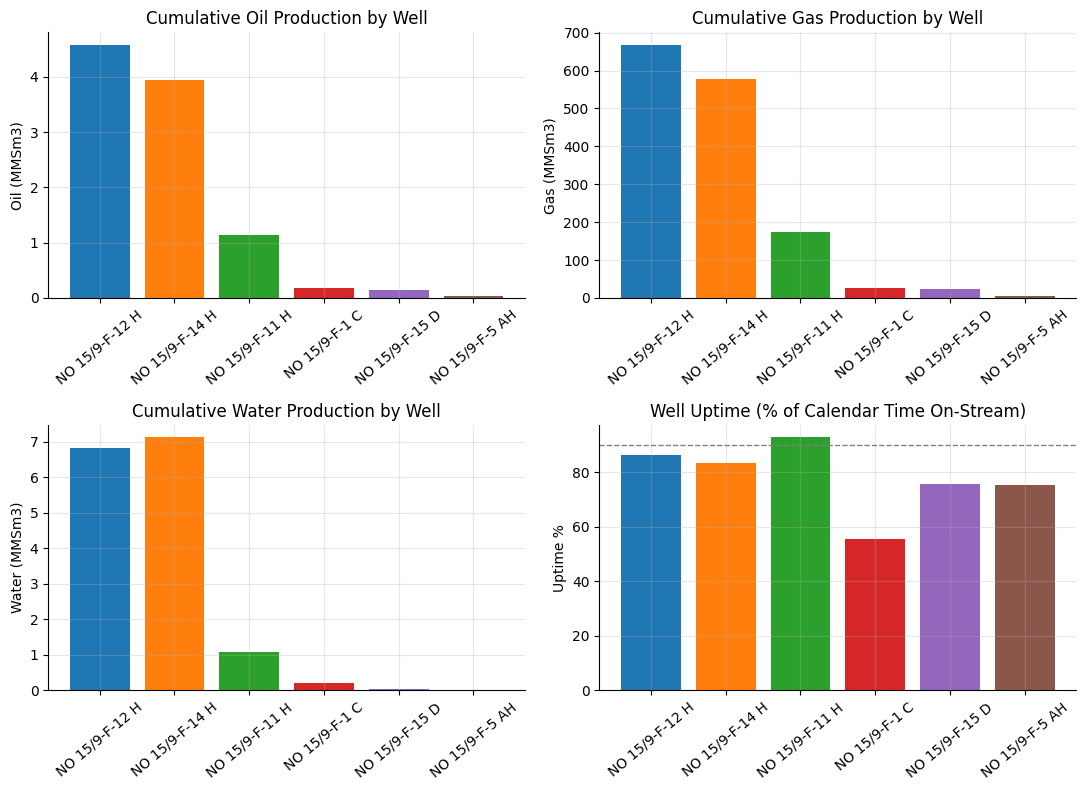

In [5]:
order = overview.WELL_BORE_CODE.tolist()
colors = [WELL_COLORS[w] for w in order]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].bar(order, overview.total_oil_sm3/1e6, color=colors)
axes[0,0].set_title('Cumulative Oil Production by Well'); axes[0,0].set_ylabel('Oil (MMSm3)')
axes[0,0].tick_params(axis='x', rotation=40)

axes[0,1].bar(order, overview.total_gas_sm3/1e6, color=colors)
axes[0,1].set_title('Cumulative Gas Production by Well'); axes[0,1].set_ylabel('Gas (MMSm3)')
axes[0,1].tick_params(axis='x', rotation=40)

axes[1,0].bar(order, overview.total_water_sm3/1e6, color=colors)
axes[1,0].set_title('Cumulative Water Production by Well'); axes[1,0].set_ylabel('Water (MMSm3)')
axes[1,0].tick_params(axis='x', rotation=40)

axes[1,1].bar(order, overview.uptime_pct, color=colors)
axes[1,1].set_title('Well Uptime (% of Calendar Time On-Stream)'); axes[1,1].set_ylabel('Uptime %')
axes[1,1].axhline(90, color='gray', ls='--', lw=1)
axes[1,1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_field_overview.png', bbox_inches='tight')
plt.show()

**Production Engineering Interpretation.** Two wells, **F-12 H (45.6%) and F-14 H (39.3%)**,
account for **~85% of all field oil** — this is the plateau. F-11 H is a solid secondary
contributor (11.4%) with the field's best uptime (92.8%). The remaining three wells — F-1 C,
F-15 D, and F-5 AH — each contribute under 2% of field oil individually.

That doesn't mean the small wells are unimportant to *this* screening exercise — a well
contributing 1.5% of field oil can still be the one showing the sharpest decline or the worst
uptime, which is exactly the kind of thing a field-wide oil-volume ranking alone would hide. Which
is why Sections 5–8 look at *rate of change*, not just total volume. What this overview does tell
an engineer immediately: any operational issue on F-12 H or F-14 H has an outsized effect on field
production, so their data quality and surveillance deserve the most attention — which is also
exactly where the downhole-gauge failure was found in Section 3.


## Section 5 — Water-Cut Analysis

Water Cut = Water / (Oil + Water). Rising water cut is one of the clearest, least ambiguous
signals a PE tracks — it directly reflects how much of the produced fluid is water instead of oil,
and rising water handling has real cost (separation capacity, disposal, sometimes workover need).


In [6]:
lifetime_wc = producers.groupby('WELL_BORE_CODE').apply(
    lambda g: g.BORE_WAT_VOL.sum() / (g.BORE_OIL_VOL.sum() + g.BORE_WAT_VOL.sum())
    if (g.BORE_OIL_VOL.sum() + g.BORE_WAT_VOL.sum()) > 0 else np.nan,
    include_groups=False
).rename('lifetime_water_cut').reset_index()
print("Lifetime (volume-weighted) water cut:")
print(lifetime_wc.sort_values('lifetime_water_cut', ascending=False).to_string(index=False))

monthly_wc = producers.set_index('DATEPRD').groupby('WELL_BORE_CODE').resample('ME').agg(
    oil=('BORE_OIL_VOL', 'sum'), wat=('BORE_WAT_VOL', 'sum')).reset_index()
monthly_wc['water_cut'] = monthly_wc.wat / (monthly_wc.oil + monthly_wc.wat)

wc_trend_rows = []
for w, g in monthly_wc.groupby('WELL_BORE_CODE'):
    g = g[(g.oil + g.wat) > 0].dropna(subset=['water_cut'])
    if len(g) < 4:
        wc_trend_rows.append({'WELL_BORE_CODE': w, 'wc_early': np.nan, 'wc_late': np.nan, 'wc_change_pts': np.nan})
        continue
    early, late = g.head(3).water_cut.mean(), g.tail(3).water_cut.mean()
    wc_trend_rows.append({'WELL_BORE_CODE': w, 'wc_early': early, 'wc_late': late,
                           'wc_change_pts': (late - early) * 100})
wc_trend = pd.DataFrame(wc_trend_rows)
wc_trend.to_csv(f'{DATA_DIR}/water_cut_trend.csv', index=False)
print("\nWater-cut trend (avg of first 3 vs last 3 producing months, percentage points):")
wc_trend.round(1)

Lifetime (volume-weighted) water cut:
WELL_BORE_CODE  lifetime_water_cut
NO 15/9-F-14 H            0.643674
NO 15/9-F-12 H            0.598752
 NO 15/9-F-1 C            0.538977
NO 15/9-F-11 H            0.487378
NO 15/9-F-15 D            0.260679
NO 15/9-F-5 AH            0.249673

Water-cut trend (avg of first 3 vs last 3 producing months, percentage points):


,WELL_BORE_CODE,wc_early,wc_late,wc_change_pts
0,NO 15/9-F-1 C,0.0,0.8,73.1
1,NO 15/9-F-11 H,0.0,0.8,82.1
2,NO 15/9-F-12 H,0.0,0.9,86.7
3,NO 15/9-F-14 H,0.0,1.0,96.3
4,NO 15/9-F-15 D,0.0,0.6,58.5
5,NO 15/9-F-5 AH,0.3,0.2,-9.8


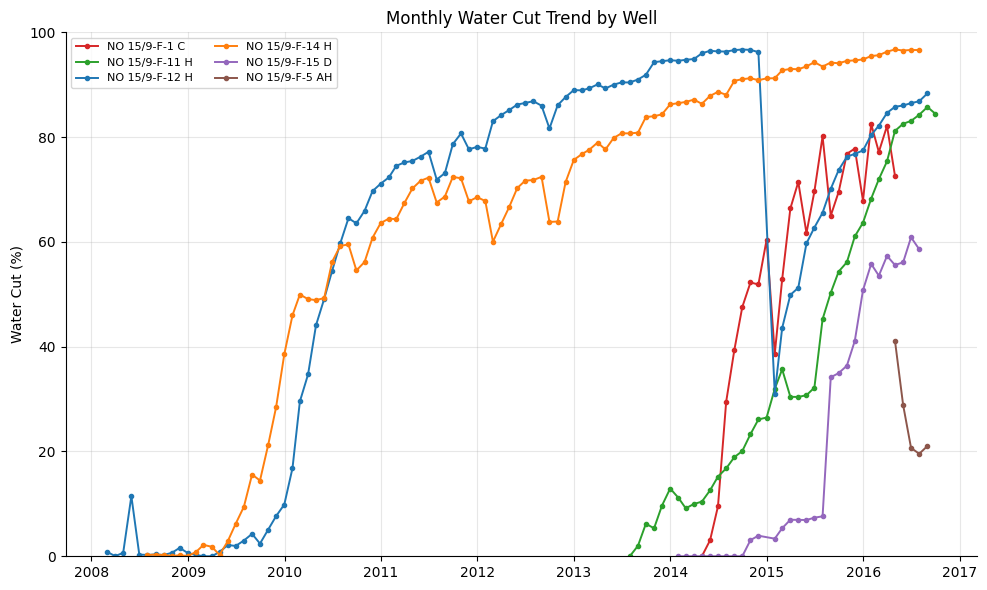

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for w in wells:
    g = monthly_wc[(monthly_wc.WELL_BORE_CODE == w) & ((monthly_wc.oil + monthly_wc.wat) > 0)]
    ax.plot(g.DATEPRD, g.water_cut * 100, marker='o', ms=3, lw=1.4, label=w, color=WELL_COLORS[w])
ax.set_ylabel('Water Cut (%)'); ax.set_title('Monthly Water Cut Trend by Well')
ax.legend(fontsize=8, ncol=2); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_water_cut_trend.png', bbox_inches='tight')
plt.show()

**Production Engineering Interpretation.** Every well with a long enough producing history
started near **0% water cut** and climbed steeply: F-14 H reaches **~97%**, F-12 H **~87%**,
F-11 H **~85%**, F-1 C **~77%**, and F-15 D **~59%** by their most recent producing months. This is
a textbook water-breakthrough pattern, consistent with Volve's peripheral water-injection scheme
(via injectors F-4 AH and, earlier, F-5 AH) eventually reaching the producers. F-5 AH is the one
exception, showing a *falling* water cut over its short producing window — but it only has ~5
months of producing data after conversion from an injector, so that trend is not yet reliable and
should not be read as "improving."

**Limitation stated explicitly:** this is a volume-based observation, not a reservoir-mechanism
claim. The data doesn't tell us *which* injector's water is breaking through into which producer,
or the exact flood-front geometry — that would need injection-allocation and possibly tracer data
this dataset doesn't contain. What the data *does* support is that water handling is now the
dominant produced-fluid issue on the field's two largest wells.


## Section 6 — Production Trend Analysis

Oil, gas, and water production over time, by well — and a simple decline-rate estimate for each.


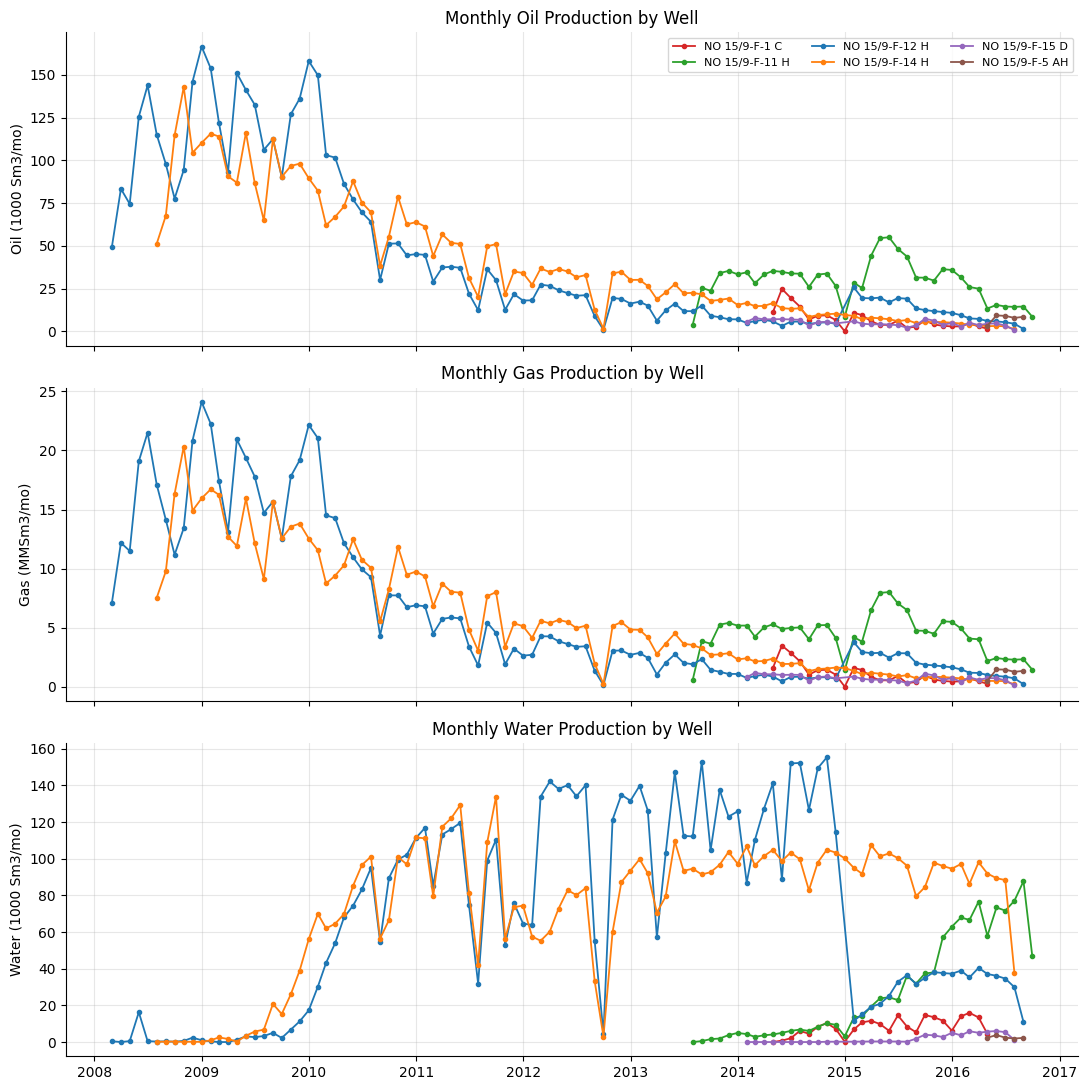

In [8]:
monthly = producers.set_index('DATEPRD').groupby('WELL_BORE_CODE').resample('ME').agg(
    oil=('BORE_OIL_VOL', 'sum'), gas=('BORE_GAS_VOL', 'sum'), wat=('BORE_WAT_VOL', 'sum'),
    hrs=('ON_STREAM_HRS', 'sum')).reset_index()
monthly.to_csv(f'{DATA_DIR}/monthly_by_well.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for w in wells:
    g = monthly[(monthly.WELL_BORE_CODE == w) & (monthly.oil + monthly.gas + monthly.wat > 0)]
    axes[0].plot(g.DATEPRD, g.oil/1000, marker='o', ms=3, lw=1.3, label=w, color=WELL_COLORS[w])
    axes[1].plot(g.DATEPRD, g.gas/1e6, marker='o', ms=3, lw=1.3, label=w, color=WELL_COLORS[w])
    axes[2].plot(g.DATEPRD, g.wat/1000, marker='o', ms=3, lw=1.3, label=w, color=WELL_COLORS[w])
axes[0].set_ylabel('Oil (1000 Sm3/mo)'); axes[0].set_title('Monthly Oil Production by Well')
axes[1].set_ylabel('Gas (MMSm3/mo)'); axes[1].set_title('Monthly Gas Production by Well')
axes[2].set_ylabel('Water (1000 Sm3/mo)'); axes[2].set_title('Monthly Water Production by Well')
axes[0].legend(fontsize=8, ncol=3, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_monthly_production_trends.png', bbox_inches='tight')
plt.show()

In [9]:
# Simple decline-rate estimate: slope of log(monthly oil) vs. time (months), log-linear fit.
# This is the standard exponential-decline read production engineers use for a first-pass check —
# not a full Arps hyperbolic/harmonic fit, which would need more assumptions than this screening
# exercise calls for.
decline_rows = []
for w, g in monthly.groupby('WELL_BORE_CODE'):
    g = g[g.oil > 0].copy()
    if len(g) < 4:
        decline_rows.append({'WELL_BORE_CODE': w, 'n_months': len(g), 'monthly_decline_pct': np.nan,
                              'peak_month_oil_sm3': g.oil.max() if len(g) else np.nan,
                              'last3mo_avg_oil_sm3': g.tail(3).oil.mean() if len(g) else np.nan,
                              'pct_below_peak': np.nan})
        continue
    g['t_months'] = (g.DATEPRD - g.DATEPRD.min()).dt.days / 30.44
    slope, intercept = np.polyfit(g.t_months, np.log(g.oil), 1)
    monthly_decline_pct = (1 - np.exp(slope)) * 100
    peak, last3 = g.oil.max(), g.tail(3).oil.mean()
    decline_rows.append({'WELL_BORE_CODE': w, 'n_months': len(g), 'monthly_decline_pct': monthly_decline_pct,
                          'peak_month_oil_sm3': peak, 'last3mo_avg_oil_sm3': last3,
                          'pct_below_peak': (1 - last3/peak) * 100})
decline = pd.DataFrame(decline_rows)
decline.to_csv(f'{DATA_DIR}/decline_analysis.csv', index=False)
decline.round(2)

,WELL_BORE_CODE,n_months,monthly_decline_pct,peak_month_oil_sm3,last3mo_avg_oil_sm3,pct_below_peak
0,NO 15/9-F-1 C,25,6.52,24901.95,3102.41,87.54
1,NO 15/9-F-11 H,39,0.79,55029.22,12525.93,77.24
2,NO 15/9-F-12 H,102,3.34,166439.67,3794.72,97.72
3,NO 15/9-F-14 H,97,3.62,142817.06,2538.28,98.22
4,NO 15/9-F-15 D,30,2.81,7898.60,2997.16,62.05
5,NO 15/9-F-5 AH,5,-18.15,9395.70,8545.50,9.05


**Production Engineering Interpretation.** F-12 H and F-14 H — the two plateau wells — are
both declining at roughly **3.3–3.6% per month** and are running at **~98% below their peak
monthly rate**, which is expected after 8+ years online but confirms they are firmly in late-life
decline, not stable plateau. F-1 C shows the steepest decline of the long-history wells
(**~6.5%/month**), consistent with the high, still-rising water cut seen in Section 5. F-11 H
shows the *shallowest* decline (**~0.8%/month**) and the best uptime — it looks like the field's
most stable performer. F-15 D sits in between.

**F-5 AH is a special case worth flagging rather than trusting at face value:** the log-linear fit
returns a large *negative* decline (i.e., apparently increasing rate) simply because it only has
~5 months of producing data right after being converted from an injector — that's a ramp-up
artifact, not a real trend, and should not be reported as "the best-performing well." This is
exactly the kind of number that looks impressive but isn't defensible with the data available —
it needs to be called out, not hidden.


## Section 7 — Operating Conditions Analysis

Do choke size, wellhead pressure, downhole pressure, and tubing pressure drop relate to oil rate?
Correlations are computed **per well**, on producing days only (`ON_STREAM_HRS > 0`), using the
on-stream-normalized oil rate (`BORE_OIL_VOL / ON_STREAM_HRS * 24`) so partial-day downtime doesn't
distort the rate. Pooling all wells together was deliberately avoided — different wells have very
different baseline rates and choke settings, so a pooled correlation would mostly reflect
*which well* a row belongs to, not the physical relationship within a well (a version of
Simpson's paradox).


In [10]:
flowing = producers[producers.ON_STREAM_HRS > 0].copy()
op_vars = ['AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DP_TUBING', 'ON_STREAM_HRS']

corr_rows = []
for w, g in flowing.groupby('WELL_BORE_CODE'):
    row = {'WELL_BORE_CODE': w, 'n': len(g)}
    for v in op_vars:
        sub = g[[v, 'OIL_RATE_ONSTREAM']].dropna()
        row[f'corr_{v}'] = sub[v].corr(sub['OIL_RATE_ONSTREAM']) if len(sub) > 10 else np.nan
    corr_rows.append(row)
corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(f'{DATA_DIR}/operating_condition_correlations.csv', index=False)
corr_df.round(2)

,WELL_BORE_CODE,n,corr_AVG_CHOKE_SIZE_P,corr_AVG_WHP_P,corr_AVG_DOWNHOLE_PRESSURE,corr_AVG_DP_TUBING,corr_ON_STREAM_HRS
0,NO 15/9-F-1 C,437,0.13,0.72,-0.27,-0.72,0.28
1,NO 15/9-F-11 H,1122,-0.43,0.20,-0.52,-0.65,0.14
2,NO 15/9-F-12 H,2838,-0.43,0.71,-0.60,0.83,0.03
3,NO 15/9-F-14 H,2724,-0.64,0.80,-0.54,-0.82,-0.01
4,NO 15/9-F-15 D,769,-0.20,0.47,0.09,-0.27,-0.09
5,NO 15/9-F-5 AH,121,0.60,0.12,NaN,NaN,0.58


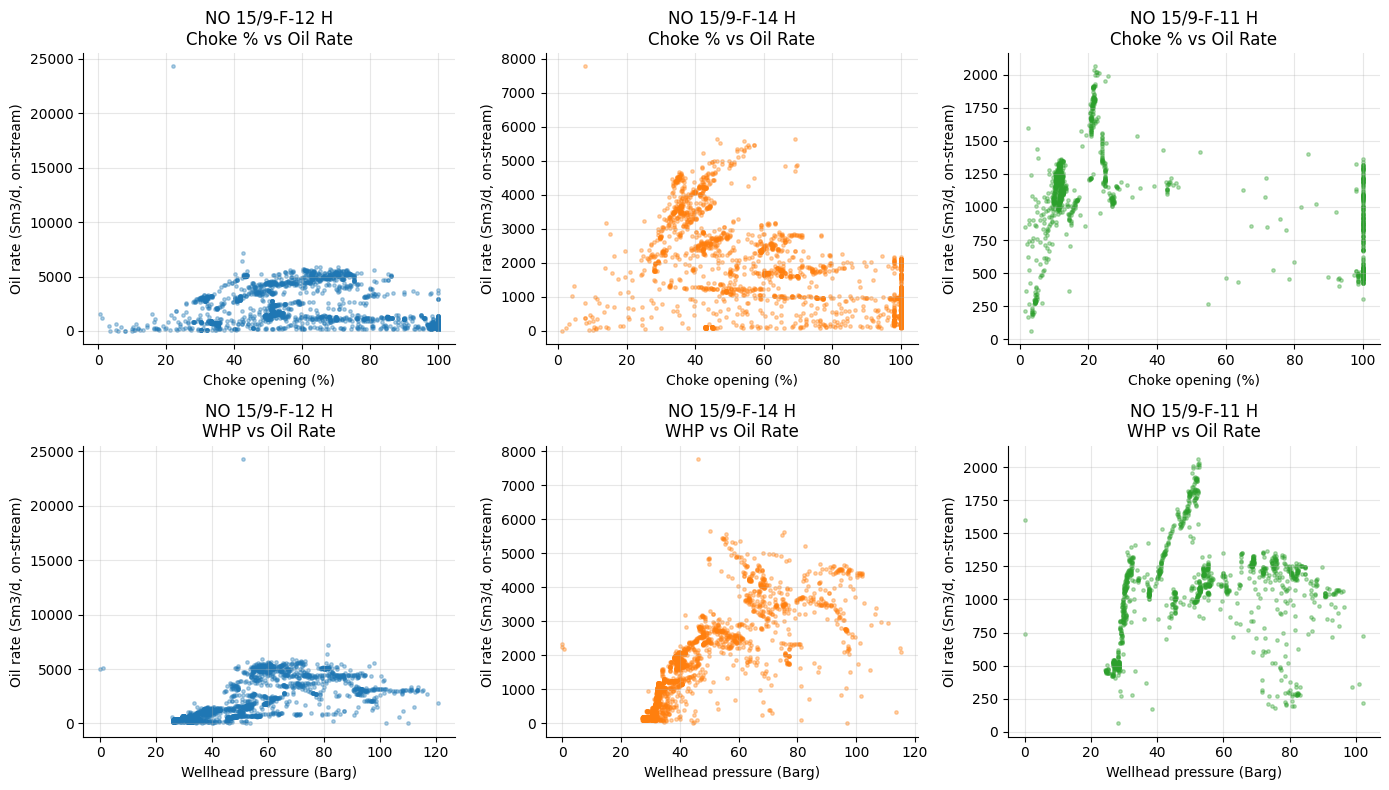

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
focus_wells = ['NO 15/9-F-12 H', 'NO 15/9-F-14 H', 'NO 15/9-F-11 H']
for i, w in enumerate(focus_wells):
    g = flowing[flowing.WELL_BORE_CODE == w]
    axes[0, i].scatter(g.AVG_CHOKE_SIZE_P, g.OIL_RATE_ONSTREAM, s=6, alpha=0.35, color=WELL_COLORS[w])
    axes[0, i].set_title(f'{w}\nChoke % vs Oil Rate')
    axes[0, i].set_xlabel('Choke opening (%)'); axes[0, i].set_ylabel('Oil rate (Sm3/d, on-stream)')
    axes[1, i].scatter(g.AVG_WHP_P, g.OIL_RATE_ONSTREAM, s=6, alpha=0.35, color=WELL_COLORS[w])
    axes[1, i].set_title(f'{w}\nWHP vs Oil Rate')
    axes[1, i].set_xlabel('Wellhead pressure (Barg)'); axes[1, i].set_ylabel('Oil rate (Sm3/d, on-stream)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_operating_conditions_scatter.png', bbox_inches='tight')
plt.show()

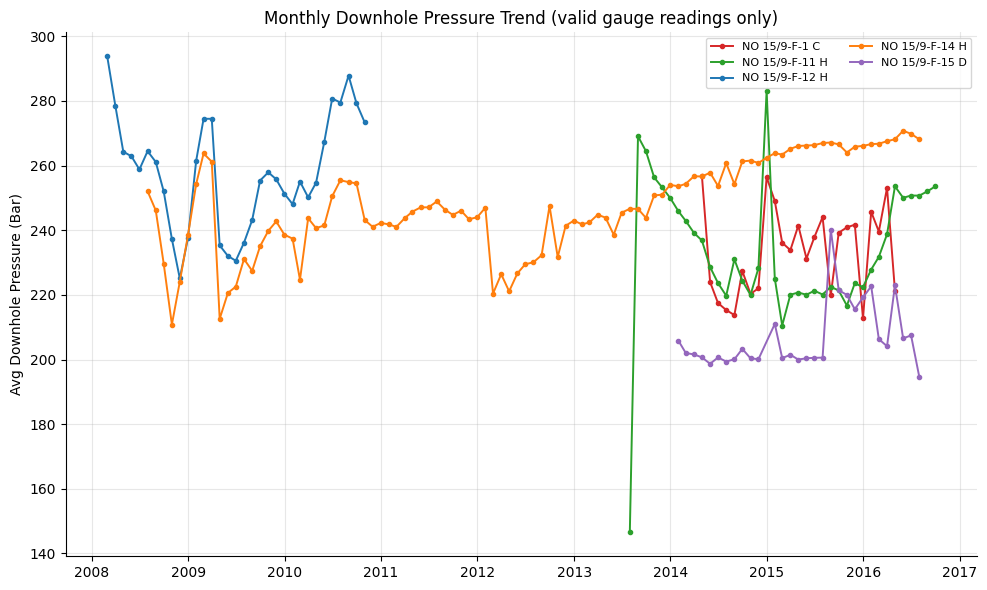

,WELL_BORE_CODE,dhp_early,dhp_late,dhp_change_pct
0,NO 15/9-F-1 C,232.8,238.0,2.2
1,NO 15/9-F-11 H,226.7,252.1,11.2
2,NO 15/9-F-12 H,278.9,280.2,0.5
3,NO 15/9-F-14 H,242.6,269.6,11.1
4,NO 15/9-F-15 D,203.1,202.9,-0.1
5,NO 15/9-F-5 AH,NaN,NaN,NaN


In [12]:
# Downhole pressure trend over time (valid gauge readings only, thanks to Section 3 cleaning)
monthly_p = flowing.set_index('DATEPRD').groupby('WELL_BORE_CODE').resample('ME').agg(
    dhp=('AVG_DOWNHOLE_PRESSURE', 'mean')).reset_index()
p_trend_rows = []
for w, g in monthly_p.groupby('WELL_BORE_CODE'):
    g = g.dropna(subset=['dhp'])
    if len(g) < 4:
        p_trend_rows.append({'WELL_BORE_CODE': w, 'dhp_early': np.nan, 'dhp_late': np.nan, 'dhp_change_pct': np.nan})
        continue
    early, late = g.head(3).dhp.mean(), g.tail(3).dhp.mean()
    p_trend_rows.append({'WELL_BORE_CODE': w, 'dhp_early': early, 'dhp_late': late,
                          'dhp_change_pct': (late - early) / early * 100 if early else np.nan})
p_trend = pd.DataFrame(p_trend_rows)
p_trend.to_csv(f'{DATA_DIR}/pressure_trend.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
for w in wells:
    g = monthly_p[monthly_p.WELL_BORE_CODE == w].dropna(subset=['dhp'])
    if len(g) == 0:
        continue
    ax.plot(g.DATEPRD, g.dhp, marker='o', ms=3, lw=1.4, label=w, color=WELL_COLORS[w])
ax.set_ylabel('Avg Downhole Pressure (Bar)')
ax.set_title('Monthly Downhole Pressure Trend (valid gauge readings only)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_downhole_pressure_trend.png', bbox_inches='tight')
plt.show()
p_trend.round(1)

**Production Engineering Interpretation — and an explicit correlation-vs-causation check.**

- **Wellhead pressure (WHP) is positively correlated with oil rate in every well** (r = +0.12 to
  +0.80). That's expected — higher flowing WHP generally goes with a well flowing harder — but it's
  as much a *symptom* of high rate as a cause of it, since WHP is itself a function of rate,
  choke, and reservoir energy together.

- **Choke opening is *negatively* correlated with oil rate in four of six wells** (e.g. r = −0.64
  on F-14 H). Taken at face value this looks backwards — opening the choke should increase rate,
  not decrease it. The likely explanation is that choke opening and oil rate are both **confounded
  by time**: chokes have been progressively opened over the years to try to sustain rate as
  reservoir pressure/oil availability declined, so late in life we see "choke wide open, rate low"
  and early in life "choke more restricted, rate high" — a time-driven pattern, not evidence that
  opening the choke *causes* lower rate. **This is exactly the kind of correlation that should
  never be read as causal without controlling for time and reservoir conditions.**

- **Downhole pressure trends are flat to slightly *increasing*** over field life on the wells with
  valid gauge data (F-1 C +2.2%, F-11 H +11.2%, F-12 H +0.5%, F-14 H +11.1%), not falling. Combined
  with the steep water-cut rise in Section 5, this points toward the observed oil decline being
  driven mainly by **rising water cut / changing fractional flow**, not by reservoir pressure
  depletion — pressure is being maintained by water injection support even as producers water out.
  This is a defensible, data-supported statement; it is *not* a claim about which specific
  injector or flood pattern is responsible, which the dataset cannot answer.

**What a Production Engineer would investigate next:** injection allocation and voidage-replacement
data to confirm the pressure-support read; water-cut vs. cumulative-oil (WOR) plots per well to
estimate remaining economic life; and a proper multi-rate/PTA-style test if a well's WHP–rate
relationship needs to be understood in isolation from time trends.


## Section 8 — Well Performance Screening

A simple, transparent screening score — not a black-box model — so it can be explained and
defended in five minutes. Four factors, each scaled 0 (least concern) to 1 (most concern) across
the six-well set, combined with fixed weights:

| Factor | Weight | Rationale |
|---|---|---|
| Decline rate (Section 6) | 0.35 | Directly measures whether the well's oil rate is falling and how fast. |
| Late-period water cut (Section 5) | 0.30 | High water cut is a leading indicator of both declining oil and rising water-handling cost. |
| Downtime (100 − uptime %, Section 4) | 0.15 | Persistent downtime is an operational/reliability issue, separate from reservoir performance. |
| Downhole pressure change (Section 7) | 0.20 | A falling pressure trend would flag depletion-driven concern distinct from water-cut effects. |

Missing values are filled with the group median so a well isn't penalized or rewarded purely for
having less data — this is disclosed, not hidden.


In [13]:
screen = overview[['WELL_BORE_CODE', 'total_oil_sm3', 'uptime_pct']].merge(
    decline[['WELL_BORE_CODE', 'monthly_decline_pct']], on='WELL_BORE_CODE', how='left'
).merge(
    wc_trend[['WELL_BORE_CODE', 'wc_late']], on='WELL_BORE_CODE', how='left'
).merge(
    p_trend[['WELL_BORE_CODE', 'dhp_change_pct']], on='WELL_BORE_CODE', how='left'
)

def norm01(s):
    s = s.copy()
    if s.notna().sum() < 2:
        return pd.Series(0.5, index=s.index)
    lo, hi = s.min(skipna=True), s.max(skipna=True)
    if hi == lo:
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)

screen['s_decline']  = norm01(screen.monthly_decline_pct.fillna(screen.monthly_decline_pct.median()))
screen['s_watercut'] = norm01(screen.wc_late.fillna(screen.wc_late.median()))
screen['s_downtime'] = norm01(100 - screen.uptime_pct)
screen['s_pressure'] = norm01((-screen.dhp_change_pct).fillna(0))

WEIGHTS = {'s_decline': 0.35, 's_watercut': 0.30, 's_downtime': 0.15, 's_pressure': 0.20}
screen['screening_score'] = sum(screen[k] * w for k, w in WEIGHTS.items()) * 100

def classify(s):
    if s >= 66: return 'High Priority'
    if s >= 40: return 'Medium Priority'
    return 'Low Priority'
screen['priority'] = screen.screening_score.apply(classify)
screen = screen.sort_values('screening_score', ascending=False).reset_index(drop=True)
screen.to_csv(f'{DATA_DIR}/well_screening.csv', index=False)

screen[['WELL_BORE_CODE', 'total_oil_sm3', 'monthly_decline_pct', 'wc_late', 'uptime_pct',
        'dhp_change_pct', 'screening_score', 'priority']].round(2)

,WELL_BORE_CODE,total_oil_sm3,monthly_decline_pct,wc_late,uptime_pct,dhp_change_pct,screening_score,priority
0,NO 15/9-F-1 C,177187.33,6.52,0.77,55.70,2.24,88.24,High Priority
1,NO 15/9-F-12 H,4579609.55,3.34,0.87,86.50,0.46,78.31,High Priority
2,NO 15/9-F-15 D,148518.56,2.81,0.59,75.79,-0.12,71.61,High Priority
3,NO 15/9-F-14 H,3942233.39,3.62,0.97,83.27,11.12,64.91,Medium Priority
4,NO 15/9-F-11 H,1146822.53,0.79,0.85,92.77,11.22,52.23,Medium Priority
5,NO 15/9-F-5 AH,38432.80,-18.15,0.20,75.40,NaN,26.81,Low Priority


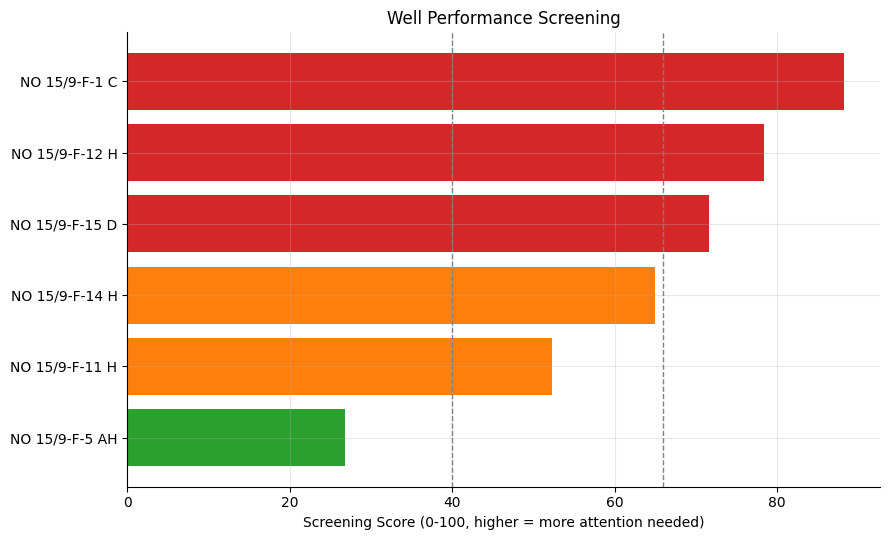

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
pc = {'High Priority': '#d62728', 'Medium Priority': '#ff7f0e', 'Low Priority': '#2ca02c'}
bar_colors = [pc[p] for p in screen.priority]
ax.barh(screen.WELL_BORE_CODE[::-1], screen.screening_score[::-1], color=bar_colors[::-1])
ax.axvline(66, color='gray', ls='--', lw=1); ax.axvline(40, color='gray', ls='--', lw=1)
ax.set_xlabel('Screening Score (0-100, higher = more attention needed)')
ax.set_title('Well Performance Screening')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_well_screening_scores.png', bbox_inches='tight')
plt.show()

**Production Engineering Interpretation.**

| Well | Score | Priority | Why |
|---|---|---|---|
| F-1 C | 88.2 | High | Steepest decline of the long-history wells (~6.5%/mo), high late water cut (~77%), and the lowest uptime (55.7%) among wells with a full history. |
| F-12 H | 78.3 | High | Field's #1 producer, but the highest late water cut of any well (~87%) and the field's largest absolute water volume — the water-management case here is about scale, not failure. |
| F-15 D | 71.6 | High | Moderate decline and water cut individually, but ranks high mainly because it's being compared against a small, six-well set — flagged with the caveat below. |
| F-14 H | 64.9 | Medium | Field's #2 producer with the field's highest late water cut (~97%), partly offset by a rising pressure trend and reasonable uptime. |
| F-11 H | 52.2 | Medium | Best uptime in the field (92.8%) and the shallowest decline — flagged Medium mainly on its still-substantial water cut (~85%). |
| F-5 AH | 26.8 | Low | Lowest score, but this reflects **data insufficiency, not confirmed good performance** — only ~5 months of producing history since conversion from an injector. |

**Two honest limitations of this screening, stated up front rather than glossed over:**
1. With only six wells, min–max normalization is sensitive to whichever well happens to be best or
   worst on a given factor — a score of 71.6 vs. 64.9 should be read as "broadly similar priority,"
   not as a precise ranking. A larger well population would make relative scoring more stable.
2. F-5 AH's low score is an artifact of limited history, not evidence the well is fine. It should
   be re-screened once 12+ months of producing data exist, not treated as "cleared."


## Section 9 — Engineering Recommendations

Recommendations are deliberately scoped to *"investigate further,"* not to specific interventions —
this dataset (daily rates, pressures, and volumes only) does not contain the well-test,
completion, or reservoir data that would justify prescribing a specific fix.

**F-1 C — High Priority.** This well should be considered for further production-performance
investigation, focused on the combination of low uptime and a fast-rising water cut. An
operating-condition review (choke history, any workovers or interventions already performed) is
recommended before further conclusions are drawn.

**F-12 H — High Priority.** Given this well's outsized contribution to field oil, it should be
prioritized for a water-management review — understanding produced-water handling capacity and
trend, rather than reservoir-performance concern, since pressure and rate trends are otherwise
consistent with the rest of the field's plateau wells.

**F-15 D — High Priority (with caveat).** This well should be considered for further surveillance
review, but the priority ranking here is more sensitive to the small comparison set than the other
High-Priority wells — it should be re-evaluated alongside the fuller field/basin well set if
available, not treated with the same confidence as F-1 C or F-12 H.

**F-14 H — Medium Priority.** Recommended for a water-management/surveillance review given its
very high late-period water cut, even though its decline rate and pressure trend are less
concerning than F-1 C's.

**F-11 H — Medium Priority.** No urgent action indicated; recommended for routine surveillance
review given its rising water cut, while noting it is otherwise the field's most stable performer.

**F-5 AH — Low Priority, but flagged for follow-up, not closure.** This well has too little
producing history for a confident screening result. It should be re-screened once more producing
months are available rather than assumed low-risk.

**What is deliberately *not* recommended:** no choke changes, artificial-lift changes, or workover
scope are proposed anywhere in this notebook. That would require well-test, mechanical, and
reservoir data outside this dataset's scope, and asserting it here would be exactly the kind of
unsupported conclusion this project is designed to avoid.


## Section 10 — Executive Summary

**Major findings.**
- Field oil production is concentrated in two wells: **F-12 H (45.6%) and F-14 H (39.3%) of total
  field oil** — together ~85%. F-11 H is a solid secondary contributor (11.4%, best uptime at
  92.8%). F-1 C, F-15 D, and F-5 AH each contribute under 2%.
- **Water cut has risen sharply on every well with sufficient history** — from near 0% early in
  each well's producing life to 59–97% in the most recent producing months. This is the dominant
  storyline in the dataset.
- **Downhole pressure is flat to slightly increasing** on the wells with valid gauge data, which
  points to the oil decline being driven primarily by rising water cut / fractional flow, not
  reservoir pressure depletion.
- **Operating-condition correlations must be read with care:** choke opening is negatively
  correlated with oil rate on most wells, almost certainly because both are confounded by time
  (chokes progressively opened as the field aged), not because opening the choke reduces rate.
- A permanent **downhole-pressure gauge failure on F-12 H** (from Oct 2010 onward, ~67% of its
  flowing days) was identified and corrected for in the cleaning step — a real surveillance gap
  worth flagging to the field team independent of this analysis.

**Highest-priority wells:** F-1 C, F-12 H, and F-15 D (screening scores 88.2, 78.3, 71.6), each for
different underlying reasons — steep decline and low uptime (F-1 C), scale of water handling on the
field's top producer (F-12 H), and a moderate-but-small-sample signal that warrants confirmation
(F-15 D).

**Key limitations.**
- Six producing wells is a small comparison set; screening scores are relative within this set, not
  absolute or universally transferable.
- No injection-allocation, well-test, or completion data was available — so *why* water cut is
  rising (which injector, which zone) cannot be determined from this dataset.
- F-5 AH has only ~5 months of producing history and should not be treated as a confirmed low-risk
  well.
- This is a screening tool for prioritizing engineering attention, not a decline-curve forecast or
  an economic model.

**Recommended next steps.** Water-management review on F-12 H and F-14 H; production-performance
investigation on F-1 C; re-screen F-15 D and F-5 AH once more data accumulates; and flag the F-12 H
downhole-gauge failure to the surveillance/instrumentation team for repair or replacement.
